In [1]:
from firedrake import *
from firedrake.output import VTKFile
import matplotlib.pyplot as plt
import numpy as np
from firedrake.petsc import PETSc
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
io_path = current_path + "/cfd-labs/Lab12-Level-Set-Method/"
print(io_path)

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


/home/aless/cfd-labs/Lab12-Level-Set-Method/


# Ex.1 Level set method for multi-phase flows

Find velocity $u$, pressure $p$, and density $\rho$ such that:

$$
\begin{cases}
\rho \,\partial_t u + \rho (u \cdot \nabla)u - \nabla \cdot (2\mu \varepsilon(u)) + \nabla p = \rho g,  & \text{in } \Omega\\
\mathrm{div} u = 0, & \text{in } \Omega\\
u = 0 & \text{on } \Gamma_B \cup \Gamma_T, \\
u \cdot n = 0,\quad n \cdot 2\mu \varepsilon(u)\,\tau = 0 & \text{on } \Gamma_L \cup \Gamma_R,\\
u(x,0) = 0 \quad & \text{in } \Omega.
\end{cases}
$$

The initial density distribution is given by

$$
\rho(x,0) =
\begin{cases}
\rho_1 & x \in \Omega_1, \\
\rho_2 & x \in \Omega_2.
\end{cases}
$$

Interface tracking: the interface between $\Omega_1$ and $\Omega_2$ is represented by $\varphi(t,x)=0$, where:

$$
\begin{cases}
\partial_t \varphi + u \cdot \nabla \varphi = 0 & \text{in } \Omega,\ t>0,\\
\varphi(x,0) = \frac{1}{2}\left[(x-0.5)^2 + (y-0.5)^2 - R^2\right] & \text{in } \Omega.
\end{cases}
$$

$\varphi$ is actually the signed distance function from the interface, considered positive in $\Omega_1$.


firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


(np.float64(-0.05), np.float64(1.05), np.float64(-0.1), np.float64(2.1))

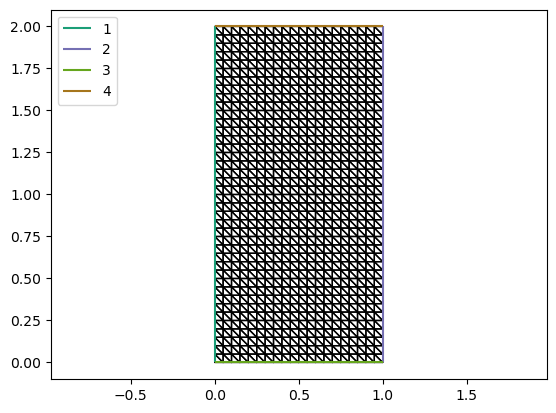

In [2]:
n = 20  # per unit length
mesh = RectangleMesh(n, 2*n, 1.0, 2.0)
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper left')
ax.axis('equal')

In [3]:
# Function spaces
V = VectorFunctionSpace(mesh, 'P', 2)   # velocity
Q = FunctionSpace(mesh, 'P', 1)         # pressure
W = MixedFunctionSpace([V, Q])
Z = FunctionSpace(mesh, 'P', 1)         # level-set function

# Data
mu = Constant(0.1)
g = Constant((0.0,-1.0))
rho1 = 10.0
rho2 = 1.e-4
T = 2.0
dt = 1.e-2

# Boundary conditions

# Velocity boundary conditions
# Free-slip on lateral walls
bcs_lateral = DirichletBC(W.sub(0).sub(0), Constant(0.0), (1, 2))
# No-slip on bottom and top walls
bcs_top_bottom = DirichletBC(W.sub(0), Constant((0.0, 0.0)), (3, 4))
bcsNS = [bcs_lateral, bcs_top_bottom]
# Null space
nullspace = MixedVectorSpaceBasis(W, [W.sub(0), VectorSpaceBasis(constant=True)])

# Level-set boundary conditions
# Homogeneous Dirichlet boundary conditions for the level-set function
# /

firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


In [9]:
# Forms and variational problems

def time_step_NS(u, v, p, q, rhoh, mu, g, dt, u_old):
    # u,p   :   TrialFunctions
    # v,q   :   TestFunctions
    # rhoh      density Function
    # u_old :   old velocity Function
    a = Constant(1/dt) * inner(rhoh * u, v) * dx + Constant(2 * mu) * inner(sym(grad(u)), sym(grad(v))) * dx  + rhoh * inner(dot(grad(u), u_old), v) * dx  - div(v) * p * dx  + q * div(u) * dx
    L = inner(rhoh * g, v) * dx + Constant(1/dt) * inner(rhoh * u_old, v) * dx
    return a, L

def time_step_level_set(phi, psi, uh, dt, phi_old):
    # phi       :   TrialFunction
    # psi       :   TestFunction
    # phi_old   :   old level-set Function
    # uh        :   advecting velocity Function
    a = Constant(1/dt) * inner(phi, psi) * dx + inner(dot(grad(phi), uh), psi) * dx
    L = Constant(1/dt) * inner(phi_old, psi) * dx
    return a, L

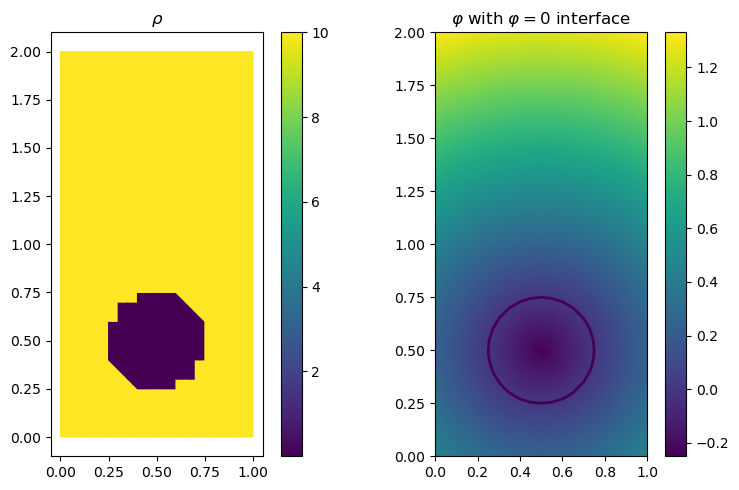

In [10]:
# Initialization
wh = Function(W)
uh, ph = wh.subfunctions

R = 0.25
phih = Function(Z)
x = SpatialCoordinate(mesh)
phih.interpolate(sqrt((x[0]-0.5)**2 + (x[1]-0.5)**2) - R)

u_old = Function(V)
u_old.assign(uh)
phi_old = Function(Z)
phi_old.assign(phih)

SMOOTHER_RHO = False
if SMOOTHER_RHO:
    rhoh = Function(Z)
    h = CellDiameter(mesh)
    heaviside = Function(Z)
    heaviside.interpolate(0.5*(1+phih/sqrt(phih**2+(h)**2)))    # fixed
    rhoh.interpolate(rho1*heaviside + rho2*(1-heaviside))       # gradient distributed over 1 element
else:
    rhoh = Function(FunctionSpace(mesh, 'DG', 0))
    rhoh.interpolate(conditional(gt(phih, 0.0), rho1, rho2))

# Plot of initial density
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

col0 = tripcolor(rhoh, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('$\\rho$')
ax[0].set_aspect('equal')

col = tripcolor(phih, axes=ax[1])
fig.colorbar(col, ax=ax[1])
x = mesh.coordinates.dat.data_ro[:, 0]
y = mesh.coordinates.dat.data_ro[:, 1]
phi = phih.dat.data_ro
from matplotlib import tri as mtri
triang = mtri.Triangulation(x, y)
ax[1].tricontour(
    triang,
    phi,
    levels=[0],
    linewidths=2
)
ax[1].set_title('$\\varphi$ with $\\varphi=0$ interface')
ax[1].set_aspect('equal')

plt.tight_layout()

# vtk output for Paraview
outdir = io_path + "output/"
outfile = VTKFile(outdir+"solution.pvd")
uh.rename("Velocity")
ph.rename("Pressure")
phih.rename("Phi")
outfile.write(uh, ph, phih)

# Define trial and test functions
u, p = TrialFunctions(W)
v, q = TestFunctions(W)
phi = TrialFunction(Z)
psi = TestFunction(Z)

In [11]:
# Time loop

nsteps = int(T/dt) + 1
mass = [0.0] * nsteps 
mass[0] = assemble(rhoh * dx)
step = 0

for t in np.linspace(dt, T, int(T/dt)):   
    step += 1

    # Step 1
    a_NS, L_NS = time_step_NS(u, v, p, q, rhoh, mu, g, dt, u_old)
    problem_NS = LinearVariationalProblem(a_NS, L_NS, wh, bcs=bcsNS)
    solver_NS = LinearVariationalSolver(problem_NS, nullspace=nullspace)
    solver_NS.solve()
    uh, ph = wh.subfunctions

    # Step 2
    a_LS, L_LS = time_step_level_set(phi, psi, uh, dt, phi_old)
    problem_LS = LinearVariationalProblem(a_LS, L_LS, phih)
    solver_LS = LinearVariationalSolver(problem_LS)
    solver_LS.solve()
    
    if (step % 10 == 0):
        uh.rename("Velocity")
        ph.rename("Pressure")
        phih.rename("Phi")
        outfile.write(uh, ph, phih, time=t)

    # Update solutions and parameters for next time step
    u_old.assign(uh)
    phi_old.assign(phih)
    if SMOOTHER_RHO:
        h = CellDiameter(mesh)
        heaviside = Function(Z)
        heaviside.interpolate(0.5*(1+phih/sqrt(phih**2+(h)**2)))    # fixed
        rhoh.interpolate(rho1*heaviside + rho2*(1-heaviside))       # gradient distributed over 1 element
    else:
        rhoh.interpolate(conditional(gt(phih, 0.0), rho1, rho2))

    mass[step] = assemble(rhoh * dx)

    print(f"Time = {t:.2f}, mass = {mass[step]:.6f}")


Time = 0.01, mass = 17.975020
Time = 0.02, mass = 17.975020
Time = 0.03, mass = 17.975020
Time = 0.04, mass = 17.987520
Time = 0.05, mass = 17.987520
Time = 0.06, mass = 17.987520
Time = 0.07, mass = 17.987520
Time = 0.08, mass = 18.025020
Time = 0.09, mass = 18.037520
Time = 0.10, mass = 18.037520
Time = 0.11, mass = 18.037520
Time = 0.12, mass = 18.037520
Time = 0.13, mass = 18.050019
Time = 0.14, mass = 18.062519
Time = 0.15, mass = 18.062519
Time = 0.16, mass = 18.050019
Time = 0.17, mass = 18.050019
Time = 0.18, mass = 18.050019
Time = 0.19, mass = 18.050019
Time = 0.20, mass = 18.050019
Time = 0.21, mass = 18.050019
Time = 0.22, mass = 18.062519
Time = 0.23, mass = 18.050019
Time = 0.24, mass = 18.050019
Time = 0.25, mass = 18.062519
Time = 0.26, mass = 18.050020
Time = 0.27, mass = 18.037520
Time = 0.28, mass = 18.050019
Time = 0.29, mass = 18.050020
Time = 0.30, mass = 18.050020
Time = 0.31, mass = 18.062519
Time = 0.32, mass = 18.075019
Time = 0.33, mass = 18.075019
Time = 0.3

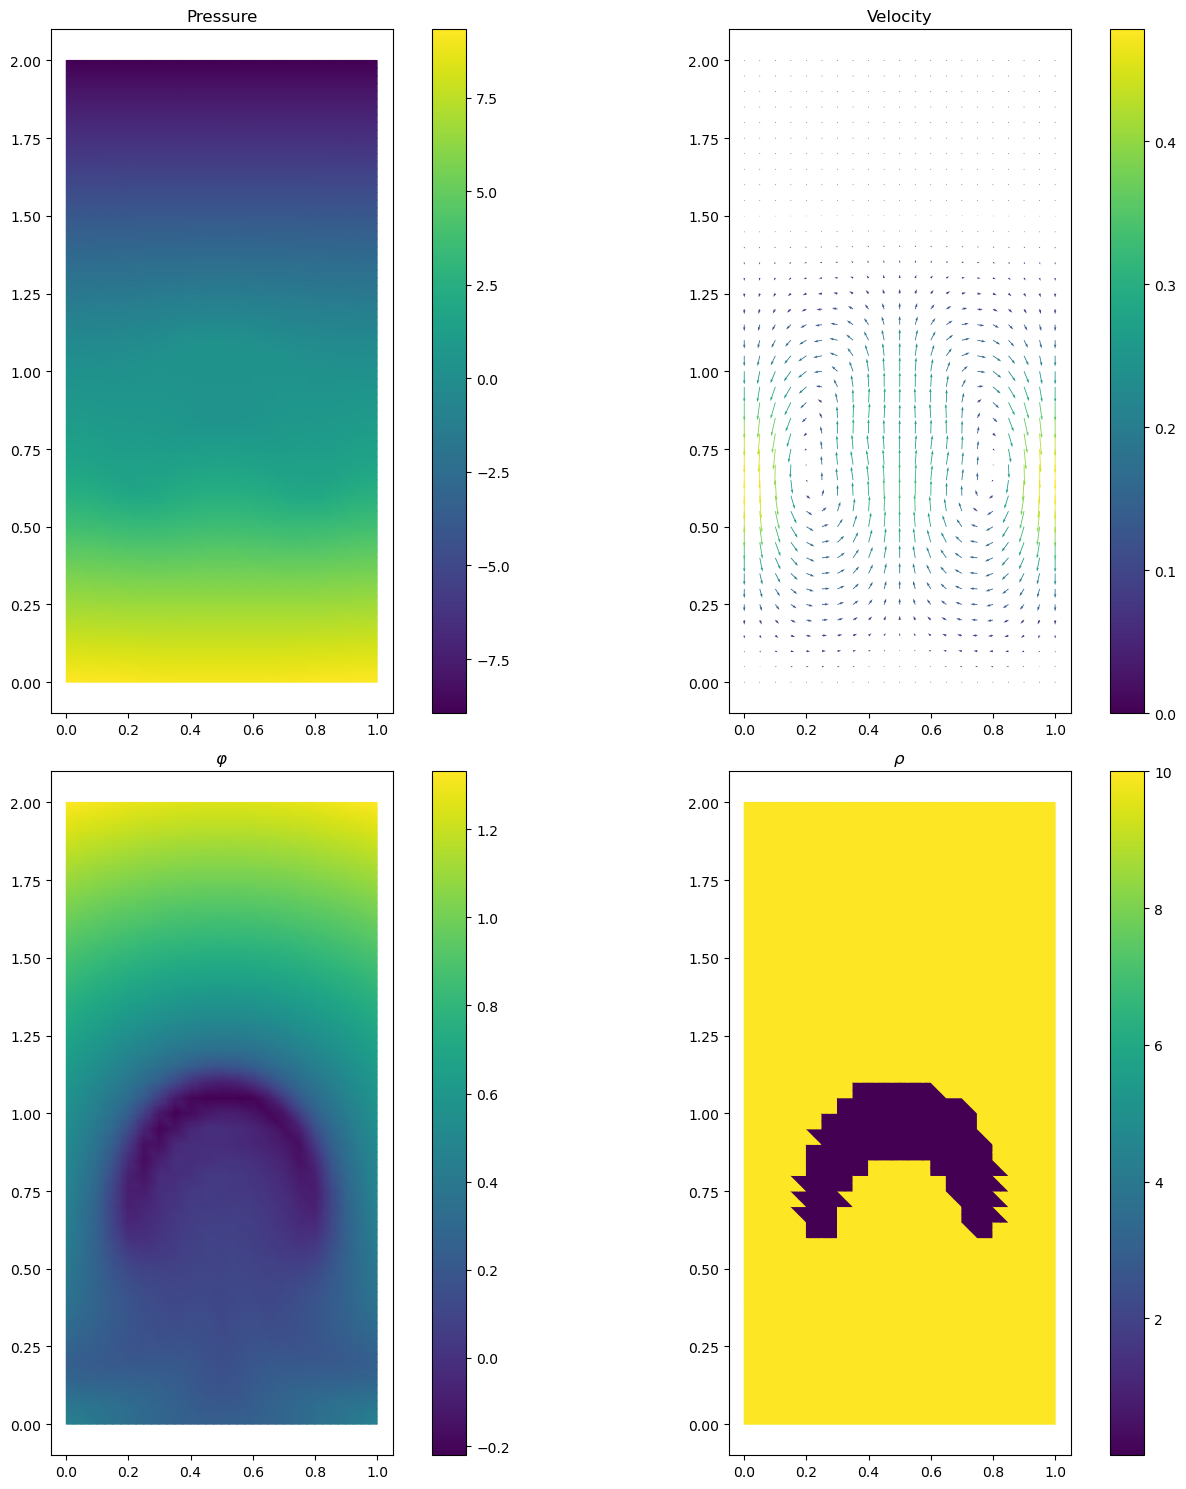

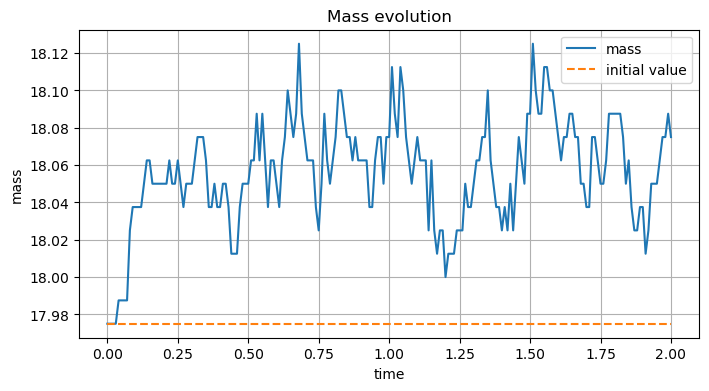

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# FIGURE 1: 4 FIELDS TOGETHER
# =========================
fig1, axs = plt.subplots(2, 2, figsize=(15, 15))

# pressure
col1 = tripcolor(ph, axes=axs[0, 0])
fig1.colorbar(col1, ax=axs[0, 0])
axs[0, 0].set_title("Pressure")
axs[0, 0].set_aspect("equal")

# velocity
col2 = quiver(uh, axes=axs[0, 1])
fig1.colorbar(col2, ax=axs[0, 1])
axs[0, 1].set_title("Velocity")
axs[0, 1].set_aspect("equal")

# phi
col3 = tripcolor(phih, axes=axs[1, 0])
fig1.colorbar(col3, ax=axs[1, 0])
axs[1, 0].set_title("$\\varphi$")
axs[1, 0].set_aspect("equal")

# rho
col4 = tripcolor(rhoh, axes=axs[1, 1])
fig1.colorbar(col4, ax=axs[1, 1])
axs[1, 1].set_title("$\\rho$")
axs[1, 1].set_aspect("equal")

fig1.tight_layout()


# =========================
# FIGURE 2: MASS EVOLUTION
# =========================
fig2, ax = plt.subplots(figsize=(8, 4))

mass_clean = [np.nan if x == 0 else x for x in mass]
mass0_line = [np.nan if x == 0 else mass[0] for x in mass]

t_vec = [0] + (dt + np.arange(0, T, dt)).tolist()

ax.plot(t_vec, mass_clean, label="mass")
ax.plot(t_vec, mass0_line, "--", label="initial value")

ax.set_title("Mass evolution")
ax.set_xlabel("time")
ax.set_ylabel("mass")
ax.legend()
ax.grid()

plt.show()